In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# 数据获取
数据中有5个维度的字段，其分别表示用户ID、商品ID、时间、行为类型、商品价格
| 列名称     | 说明                                 |
| ---------- | ------------------------------------ |
| 用户ID     | 整数类型，序列化后的用户ID           |
| 商品ID     | 整数类型，序列化后的商品ID           |
| 商品类别ID | 整数类型，序列化后的商品所属类别ID   |
| 行为类型   | 字符串，枚举类型，包括('pv','buy','cart','fav') |
| 时间戳     | 行为发生的时间戳                     |

其中用户行为类型共有四种，它们分别是

| 行为类型 | 说明             |
| -------- | ---------------- |
| pv       | 商品详情页 pv，等价于点击 |
| buy      | 商品购买         |
| cart     | 将商品加入购物车 |
| fav      | 收藏商品         |

In [4]:
df = pd.read_csv(r"C:\Users\16049\Desktop\UserBehavior.csv", nrows=200000, names=['用户ID','商品ID','商品类目ID','行为类型','时间戳'])
print(f'数据规模：{df.shape[0]}条用户行为记录，{df.shape[1]}个字段')
df.head()

数据规模：200000条用户行为记录，5个字段


,用户ID,商品ID,商品类目ID,行为类型,时间戳
0,1,2268318,2520377,pv,1511544070
1,1,2333346,2520771,pv,1511561733
2,1,2576651,149192,pv,1511572885
3,1,3830808,4181361,pv,1511593493
4,1,4365585,2520377,pv,1511596146


# 数据处理

In [63]:
#数据清洗与预处理
print('字段类型与非空统计',df.info())
print('缺失值统计',df.isnull().sum())
print('重复值统计',df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   用户ID    200000 non-null  int64 
 1   商品ID    200000 non-null  int64 
 2   商品类目ID  200000 non-null  int64 
 3   行为类型    200000 non-null  object
 4   时间戳     200000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 7.6+ MB
字段类型与非空统计 None
缺失值统计 用户ID      0
商品ID      0
商品类目ID    0
行为类型      0
时间戳       0
dtype: int64
重复值统计 0


# 数据类型转换


In [64]:
df['行为时间'] = pd.to_datetime(df['时间戳'], unit='s', origin=pd.Timestamp('1970-01-01'), utc=True).dt.tz_convert('Asia/Shanghai')
df['行为日期'] = df['行为时间'].dt.date
df['行为小时'] = df['行为时间'].dt.hour
df['行为星期'] = df['行为时间'].dt.weekday.map({0: '周一', 1: '周二', 2: '周三', 3: '周四', 4: '周五', 5: '周六', 6: '周日'})

# 异常值过滤
数据集有效范围为 2017-11-25 至 2017-12-03，超出的是脏数据，会影响分析结果

In [65]:
start_date = datetime.date(2017,11,25)
end_date = datetime.date(2017,12,5)
df = df[(df['行为日期'] >= start_date) & (df['行为日期'] <= end_date)]

# 数据清洗


In [66]:
# 去除重复值
df.drop_duplicates()
# 保留四种合规的行为类型
df = df[df['行为类型'].isin(['pv', 'buy', 'cart', 'fav'])]

# 清洗结果

In [67]:
print('清洗后的有效数据量：', df.shape[0], '条记录')
print('数据覆盖的时间范围：', df['行为日期'].min(), '至', df['行为日期'].max())
print('覆盖用户数量：', df['用户ID'].nunique())
print('覆盖商品数量：', df['商品ID'].nunique())
print('覆盖商品类目数量：', df['商品类目ID'].nunique())
df.head()

清洗后的有效数据量： 199908 条记录
数据覆盖的时间范围： 2017-11-25 至 2017-12-03
覆盖用户数量： 1973
覆盖商品数量： 117031
覆盖商品类目数量： 3980


,用户ID,商品ID,商品类目ID,行为类型,时间戳,行为时间,行为日期,行为小时,行为星期
0,1,2268318,2520377,pv,1511544070,2017-11-25 01:21:10+08:00,2017-11-25,1,周六
1,1,2333346,2520771,pv,1511561733,2017-11-25 06:15:33+08:00,2017-11-25,6,周六
2,1,2576651,149192,pv,1511572885,2017-11-25 09:21:25+08:00,2017-11-25,9,周六
3,1,3830808,4181361,pv,1511593493,2017-11-25 15:04:53+08:00,2017-11-25,15,周六
4,1,4365585,2520377,pv,1511596146,2017-11-25 15:49:06+08:00,2017-11-25,15,周六


# 电商核心指标计算
我们先从宏观的流量分析，我们要关注**访问量（PV）**和**点击量（UV）**。

In [68]:
#流量类指标
total_pv = df[df['行为类型'] == 'pv'].shape[0] #总点击量（PV
total_uv = df[df['行为类型'] == 'pv']['用户ID'].nunique()#总独立访问数
avg_pv_per_uv = round(total_pv / total_uv, 2) #人均点击量


In [69]:
#转化类指标
total_cart = df[df['行为类型'] == 'cart'].shape[0] #总加购量
total_fav = df[df['行为类型'] == 'fav'].shape[0] #总收藏量
total_buy = df[df['行为类型'] == 'buy'].shape[0] #总购买量
pay_user_count = df[df['行为类型'] == 'pay'].shape[0] #购买用户数

click_to_cart_rate = round(total_cart / total_pv * 100, 2) #点击加购率
click_to_fav_rate = round(total_fav / total_pv * 100, 2) #点击-收藏率
click_to_buy_rate = round(total_buy / (total_cart + total_fav) * 100, 2) #点击-购买率
cart_to_buy_rate = round(total_buy / total_pv * 100, 2) #点击-最终购买转化率
pay_rate = round(pay_user_count / total_buy * 100, 2) #用户付费率


# 核心指标看板搭建


In [70]:
print('='*50)
print('淘宝用户行为核心指标看板')
print('='*50)
print(f'1.流量规模:总点击量PV={total_pv},总独立访问数UV={total_uv}，人均点击量={avg_pv_per_uv}')
print(f'2.转化效率：点击加购率={click_to_cart_rate}%，点击-收藏率={click_to_fav_rate}%')
print(f'点击-购买率={click_to_buy_rate}%，点击-最终购买转化率={cart_to_buy_rate}%，用户付费率={pay_rate}%')
print('='*50)

淘宝用户行为核心指标看板
1.流量规模:总点击量PV=179739,总独立访问数UV=1967，人均点击量=91.38
2.转化效率：点击加购率=6.07%，点击-收藏率=2.75%
点击-购买率=27.33%，点击-最终购买转化率=2.41%，用户付费率=0.0%


# 用户全链路转化漏斗分析


       行为环节     用户数     环节转化率     整体转化率
0    点击(PV)  179739  100.0000  100.0000
1  加购(Cart)   10906    6.0677    6.0677
2   收藏(Fav)    4934   45.2412    2.7451
3   购买(Buy)    4329   87.7381    2.4085


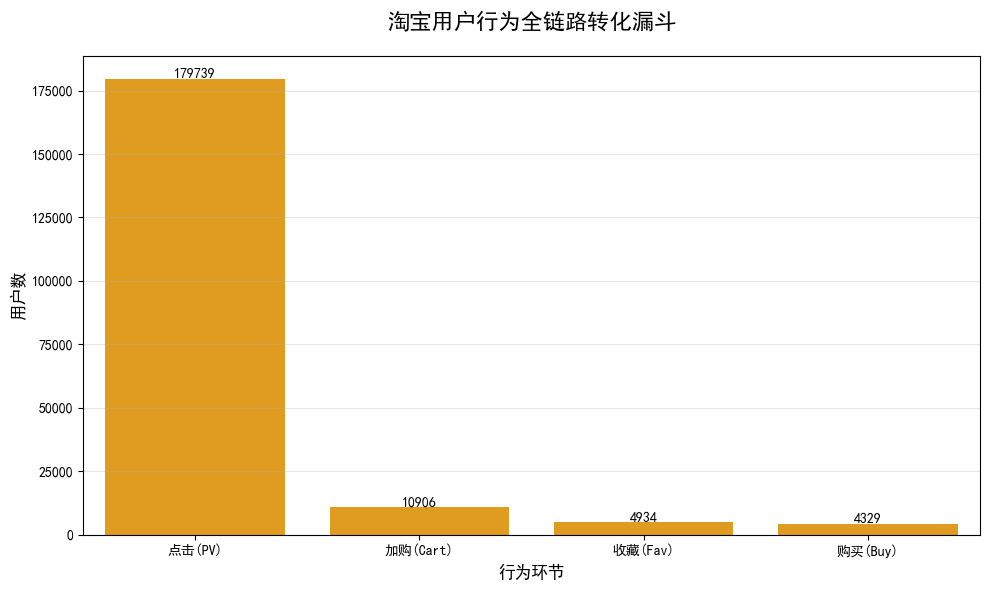

In [71]:
#构建漏斗各环节数据
funnel_data = pd.DataFrame({
    '行为环节':['点击(PV)', '加购(Cart)', '收藏(Fav)', '购买(Buy)'],
    '用户数':[total_pv, total_cart, total_fav, total_buy]
})
#计算各环节转化率与流失率
funnel_data['环节转化率'] = round(funnel_data['用户数'] / funnel_data['用户数'].shift(1) * 100, 4)
funnel_data['整体转化率'] = round(funnel_data['用户数']/total_pv * 100, 4)
funnel_data.loc[0,'环节转化率'] = 100 #起始环节转化率100%
print(funnel_data)

#漏斗可视化
plt.figure(figsize=(10,6))
sns.barplot(data=funnel_data, x='行为环节', y='用户数', color='#FFA500')
plt.title('淘宝用户行为全链路转化漏斗',fontsize=16,pad=20)
plt.xlabel('行为环节',fontsize=12)
plt.ylabel('用户数',fontsize=12)

#在柱子上标注数值和转化率
for i in range(len(funnel_data)):
    plt.text(i,funnel_data['用户数'][i]+100,funnel_data['用户数'][i],ha='center')
plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

# 时间维度用户行为分析


日维度活跃趋势


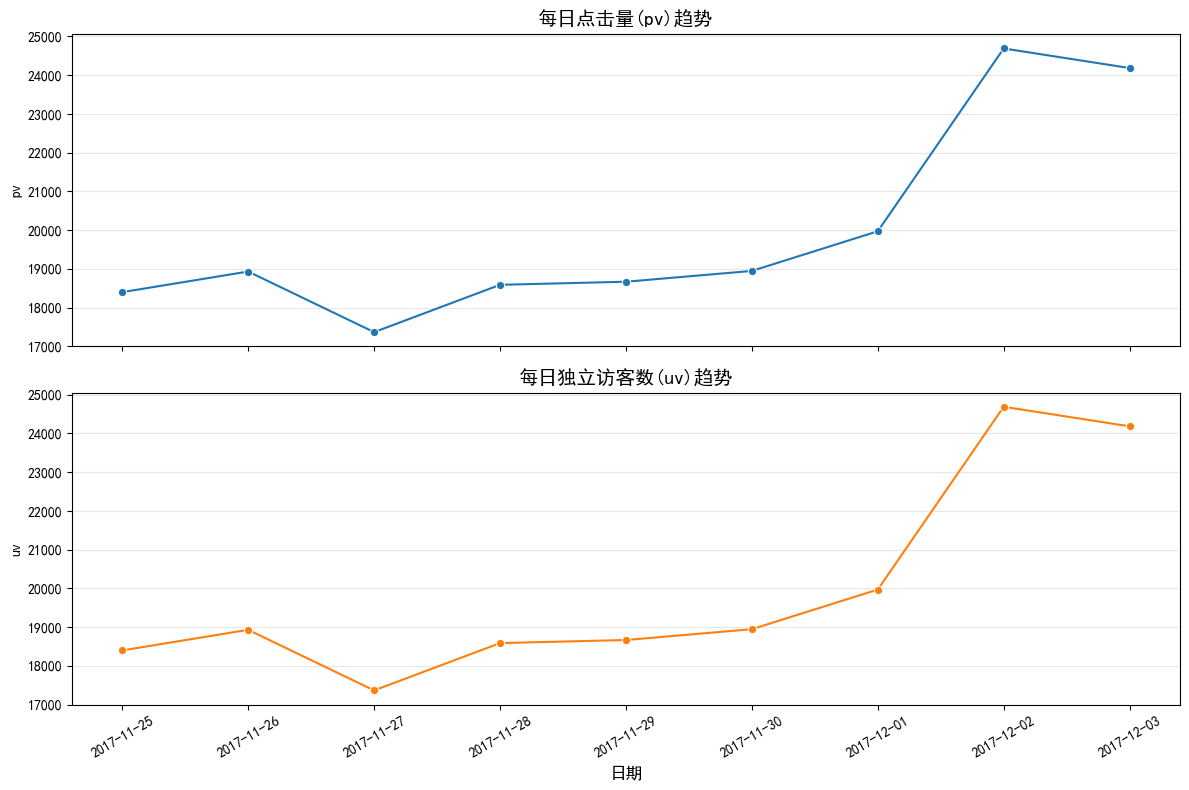

In [72]:
daily_pv = df[df['行为类型']=='pv'].groupby('行为日期')['行为类型'].count().reset_index(name='pv')
daily_uv = df[df['行为类型']=='pv'].groupby('行为日期')['行为类型'].count().reset_index(name='uv')
daily_trend = pd.merge(daily_pv, daily_uv, on='行为日期')

#日趋可视化
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(12,8),sharex=True)
sns.lineplot(data = daily_trend, x='行为日期', y='pv', marker= 'o', color = '#1f77b4', ax=ax1)
ax1.set_title('每日点击量(pv)趋势', fontsize=14)
ax1.grid(axis='y',alpha=0.3)

sns.lineplot(data = daily_trend, x='行为日期', y='uv', marker= 'o', color = '#ff7f0e', ax=ax2)
ax2.set_title('每日独立访客数(uv)趋势', fontsize=14)
ax2.set_xlabel('日期', fontsize=12)
ax2.grid(axis='y',alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

小时维度用户活跃规律

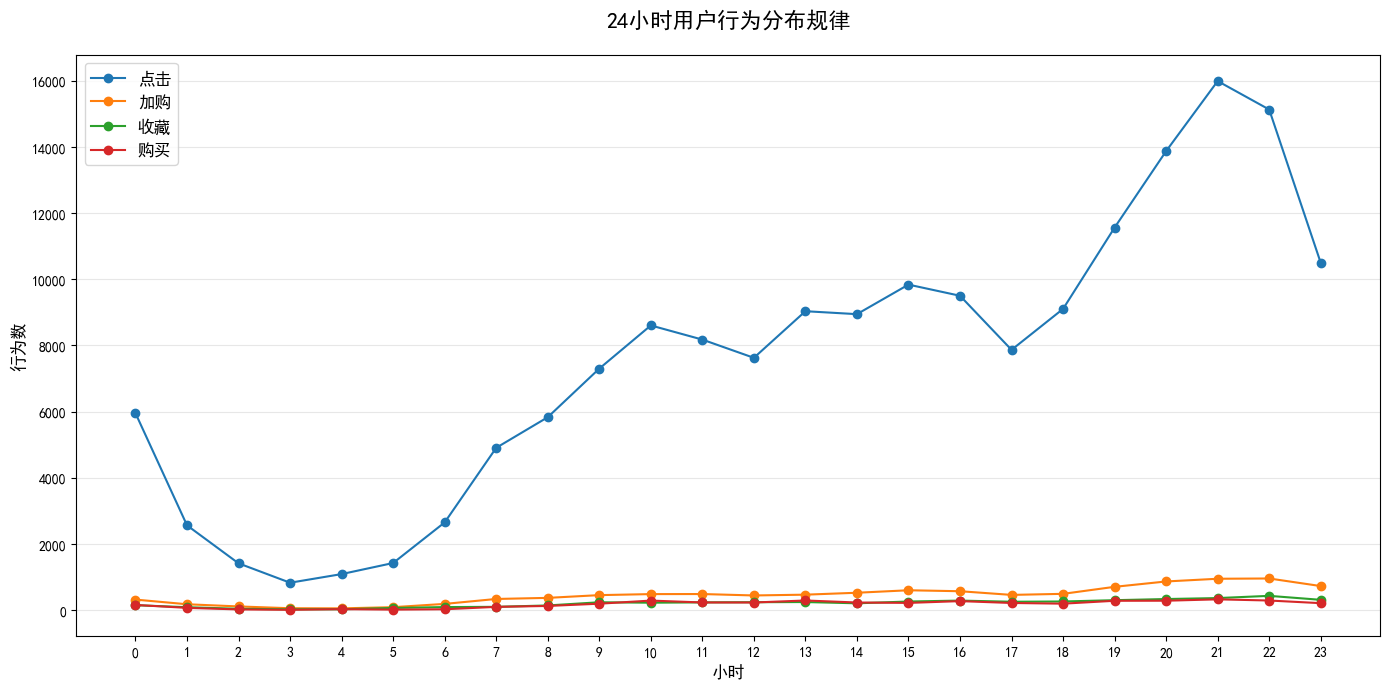

In [73]:
hourly_action = df.groupby(['行为小时','行为类型'])['用户ID'].count().reset_index(name='行为数')
hourly_pivot = hourly_action.pivot(index='行为小时',columns='行为类型',values='行为数').fillna(0)

plt.figure(figsize=(14,7))
for action in ['pv','cart','fav','buy']:
    plt.plot(hourly_pivot.index,hourly_pivot[action],marker='o',label=action)
plt.title('24小时用户行为分布规律',fontsize = 16 ,pad=20)
plt.xlabel('小时',fontsize =12)
plt.ylabel('行为数',fontsize =12)
plt.xticks(range(0,24))
plt.legend(['点击','加购','收藏','购买'],fontsize = 12)
plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()




# 基于RF模型的用户价值分层 

In [81]:
#计算每个付费用户的R值和F值
buy_df = df[df['行为类型']== 'buy']
analysis_end_date = end_date #分析日期截止：2017-12-03

#计算R值：最近一次购买距离结束日期的天数
user_r = buy_df.groupby('用户ID')['行为日期'].max().reset_index()
user_r['R值'] = user_r['行为日期'].apply(lambda x: (analysis_end_date - x).days)

#用户购买次数
user_f = buy_df.groupby('用户ID')['行为类型'].count().reset_index(name = 'F值')

#合并RF指标
user_rf = pd.merge(user_r[['用户ID','R值']],user_f,on='用户ID')



# RF指标打分

In [82]:
#RF指标打分（1-5分,分值越高,用户价值越高）
#R值：越小越好,反向打分
user_rf['R打分'] = pd.cut(user_rf['R值'],bins=[-1,1,2,3,4,9],labels=[5,4,3,2,1])
#F值：越大越号，正向打分
user_rf['F打分'] = pd.cut(user_rf['F值'],bins=[0,1,2,3,5,100],labels=[1,2,3,4,5])

#用户价值分层
def user_level(row):
    if row['R打分'] >= 4 and row['F打分'] >=4:
        return'重要价值用户'
    elif row['R打分'] >= 4 and row['F打分'] < 4:
        return'重要发展用户'
    elif row['R打分'] < 4 and row['F打分'] >=4:
        return'重要挽留用户'
    elif row['R打分'] >=3 and row['F打分'] >= 3:
        return'一般价值用户'
    elif row['R打分'] >=3 and row['F打分'] < 3:
        return'新用户'
    elif row['R打分'] < 3 and row['F打分'] >=3:
        return'流失预警用户'
    else:
        return'低价值用户'
    

user_rf['用户分层'] = user_rf.apply(user_level,axis=1)

# RF分层结果可视化

==== 用户价值分层结果 ====
     用户分层  用户数量     占比
0   低价值用户   478  34.92
1  重要挽留用户   223  16.29
2  重要发展用户   196  14.32
3  重要价值用户   165  12.05
4     新用户   150  10.96
5  流失预警用户   114   8.33
6  一般价值用户    43   3.14


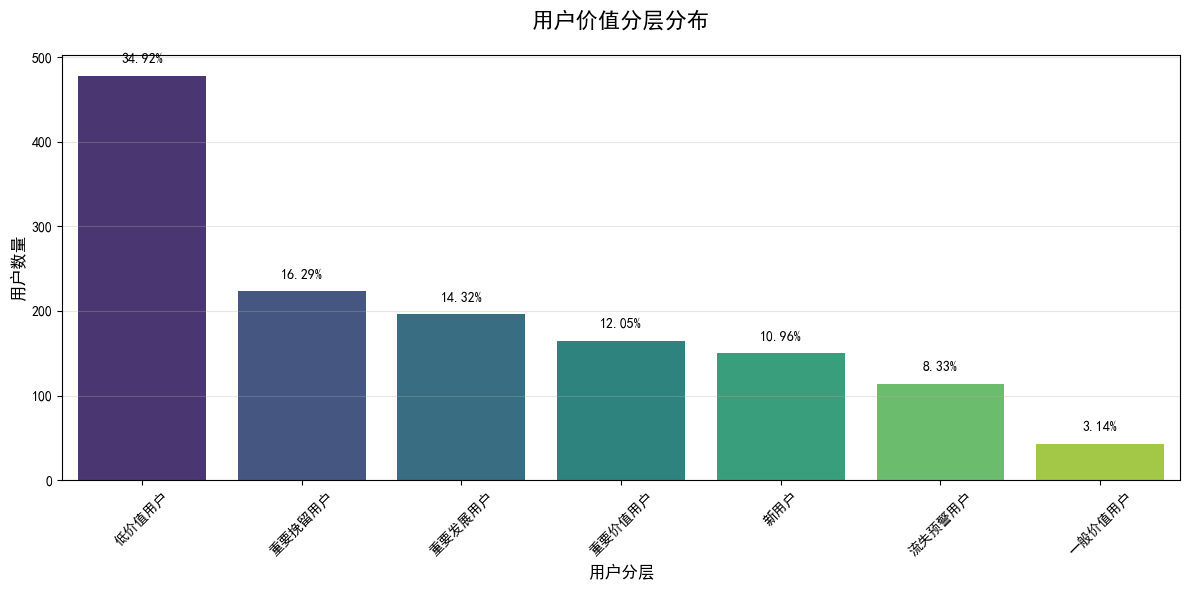

In [89]:
user_level_count = user_rf['用户分层'].value_counts().reset_index()
user_level_count.columns = ['用户分层', '用户数量']
user_level_count['占比'] = round(user_level_count['用户数量'] / user_level_count['用户数量'].sum() * 100,2)

print('==== 用户价值分层结果 ====')
print(user_level_count.sort_values('用户数量', ascending=False))

#分层可视化
plt.figure(figsize=(12,6))
sns.barplot(data=user_level_count, x='用户分层', y='用户数量', palette='viridis')
plt.title('用户价值分层分布',fontsize = 16 ,pad=20)
plt.xlabel('用户分层',fontsize = 12)
plt.ylabel('用户数量',fontsize = 12)
plt.xticks(rotation = 45)
#标注占比
for i, v in enumerate(user_level_count['用户数量']):  
    plt.text(i, v+15, str(user_level_count['占比'][i])+'%', ha='center')
plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

# 商品类目分析


===== TOP10点击量类目 =====
       商品类目ID   点击量   购买量   购买转化率
3597  4756105  8233  39.0  0.4737
2754  3607361  6953  32.0  0.4602
3174  4145813  5823  62.0  1.0647
753    982926  5682  34.0  0.5984
1775  2355072  5609  30.0  0.5349
1896  2520377  3889  16.0  0.4114
3637  4801426  3406  47.0  1.3799
1001  1320293  3365  28.0  0.8321
1852  2465336  2835  27.0  0.9524
2281  3002561  2662  38.0  1.4275

===== TOP10购买量类目 =====
       商品类目ID   点击量   购买量    购买转化率
1116  1464116  1248  71.0   5.6891
2079  2735466  2038  64.0   3.1403
2195  2885642  1596  63.0   3.9474
3174  4145813  5823  62.0   1.0647
3637  4801426  3406  47.0   1.3799
687    901282   124  47.0  37.9032
3338  4357323  1442  40.0   2.7739
3597  4756105  8233  39.0   0.4737
2281  3002561  2662  38.0   1.4275
2002  2640118  1856  37.0   1.9935


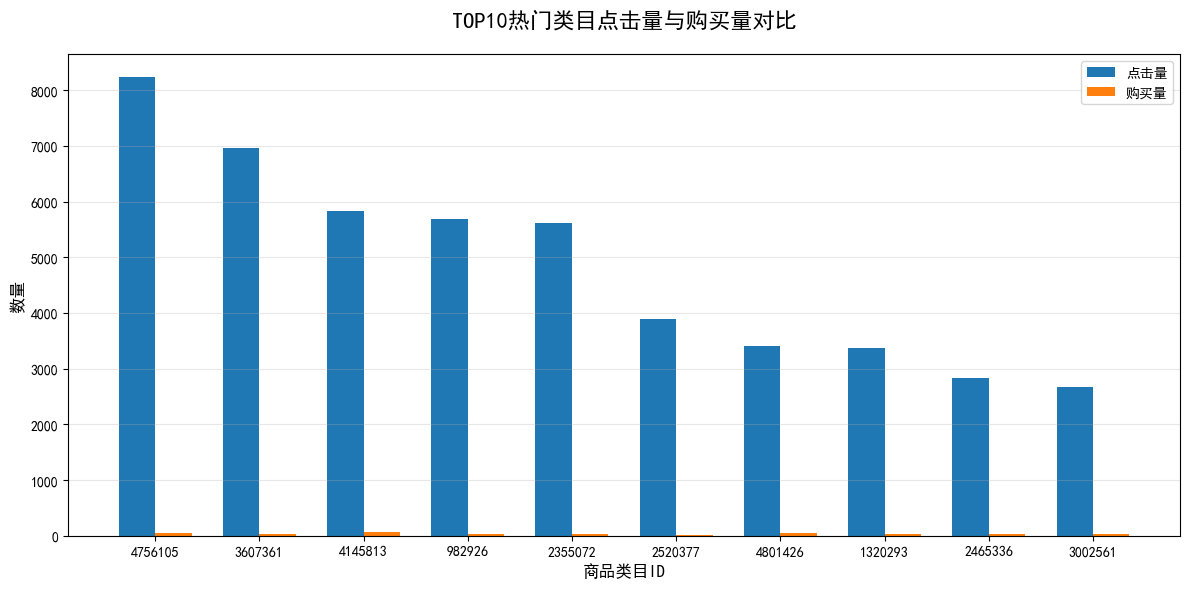

In [90]:

#统计每个类目的点击量、购买量
category_pv = df[df['行为类型'] == 'pv'].groupby('商品类目ID')['行为类型'].count().reset_index(name='点击量')
category_buy = df[df['行为类型'] == 'buy'].groupby('商品类目ID')['行为类型'].count().reset_index(name='购买量')
category_analysis = pd.merge(category_pv, category_buy, on='商品类目ID', how='left').fillna(0)

# 计算类目转化率
category_analysis['购买转化率'] = round(category_analysis['购买量'] / category_analysis['点击量'] * 100, 4)

# TOP10热门类目分析
top10_pv_category = category_analysis.sort_values('点击量', ascending=False).head(10)
top10_buy_category = category_analysis.sort_values('购买量', ascending=False).head(10)

print("===== TOP10点击量类目 =====")
print(top10_pv_category)
print("\n===== TOP10购买量类目 =====")
print(top10_buy_category)

# 可视化：TOP10类目点击量vs购买量
plt.figure(figsize=(12, 6))
x = np.arange(len(top10_pv_category['商品类目ID']))
width = 0.35
plt.bar(x - width/2, top10_pv_category['点击量'], width, label='点击量', color='#1f77b4')
plt.bar(x + width/2, top10_pv_category['购买量'], width, label='购买量', color='#ff7f0e')
plt.title('TOP10热门类目点击量与购买量对比', fontsize=16, pad=20)
plt.xlabel('商品类目ID', fontsize=12)
plt.ylabel('数量', fontsize=12)
plt.xticks(x, top10_pv_category['商品类目ID'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()